# Eksperimen Pencarian Jalur Robot Humanoid

Notebook ini menyajikan eksperimen yang digunakan dalam makalah: Brute Force
berbasis waypoint, keluarga pencarian grid UCS/GBFS/A*, dan RRT* pada lapangan
60 x 40 dengan hambatan statis.

Fokus analisis:

- kualitas dan keberhasilan lintasan;
- waktu eksekusi dan variasinya;
- jumlah kandidat atau simpul yang diproses;
- perubahan perilaku A* ketika heuristik tidak lagi cukup informatif.

## Formulasi eksperimen

Masukan setiap percobaan adalah peta, posisi awal, posisi tujuan, dan seed.
Keluaran adalah lintasan bebas tabrakan atau status gagal. Biaya lintasan dihitung
sebagai jumlah jarak antar titik berurutan.

| Kelompok | Representasi | Prioritas / strategi | Arti `processed` |
|---|---|---|---|
| Brute Force | waypoint kontinu | enumerasi sampai tiga waypoint | kandidat rute |
| UCS | grid 8 arah | `g(n)` | simpul grid |
| GBFS | grid 8 arah | `h(n)` | simpul grid |
| A* | grid 8 arah | `g(n) + h(n)` | simpul grid |
| RRT* | ruang kontinu | sampling dan rewiring | node pohon |

Nilai `processed` hanya dibandingkan langsung untuk metode dengan representasi
yang sama.

In [1]:
from pathlib import Path
import math
import time

import matplotlib.pyplot as plt
from matplotlib.patches import Circle as CirclePatch, Rectangle
import numpy as np
import pandas as pd
from IPython.display import display

from asa_path_planning.experiment import (
    ALGORITHM_ORDER,
    SCENARIOS,
    START,
    GOAL,
    RunResult,
    RRTStarResult,
    a_star_search,
    brute_force_waypoints,
    cell_center,
    greedy_best_first_search,
    is_free_cell,
    line_free,
    rrt_star,
    scenario_from_seed,
    uniform_cost_search,
)


def project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Root project tidak ditemukan")


ROOT = project_root(Path.cwd().resolve())
DATA_DIR = ROOT / "results" / "data"

COLORS = {
    "Brute Force": "#4C78A8",
    "UCS": "#F58518",
    "GBFS": "#54A24B",
    "A*": "#E45756",
    "RRT*": "#8E6CBB",
}

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.grid": True,
        "grid.alpha": 0.2,
        "font.size": 10,
    }
)

In [2]:
GRID_METHODS = {"UCS", "GBFS", "A*"}


def draw_field(axis, scenario, title=None):
    axis.set_xlim(0, scenario.width)
    axis.set_ylim(0, scenario.height)
    axis.set_aspect("equal")
    axis.set_facecolor("#F7FAF8")

    for obstacle in scenario.circles:
        axis.add_patch(
            CirclePatch(
                (obstacle.x, obstacle.y),
                obstacle.r,
                facecolor="#7F8C8D",
                edgecolor="#4F5B5C",
                alpha=0.58,
            )
        )
    for obstacle in scenario.rects:
        axis.add_patch(
            Rectangle(
                (obstacle.x1, obstacle.y1),
                obstacle.x2 - obstacle.x1,
                obstacle.y2 - obstacle.y1,
                facecolor="#7F8C8D",
                edgecolor="#4F5B5C",
                alpha=0.58,
            )
        )

    start = cell_center(scenario.start)
    goal = cell_center(scenario.goal)
    axis.scatter(*start, s=45, color="#1B9E77", marker="o", zorder=5)
    axis.scatter(*goal, s=55, color="#D95F02", marker="X", zorder=5)
    axis.set_xticks(range(0, scenario.width + 1, 10))
    axis.set_yticks(range(0, scenario.height + 1, 10))
    axis.set_title(title or scenario.name)


def path_xy(method, path):
    if method in GRID_METHODS:
        return (
            [cell[0] + 0.5 for cell in path],
            [cell[1] + 0.5 for cell in path],
        )
    return ([point[0] for point in path], [point[1] for point in path])


def path_is_valid(method, scenario, result):
    if not result.success or len(result.path) < 2:
        return False

    if method in GRID_METHODS:
        if not all(is_free_cell(scenario, cell) for cell in result.path):
            return False
        points = [cell_center(cell) for cell in result.path]
    else:
        points = result.path

    return all(line_free(scenario, a, b, step=0.5) for a, b in zip(points, points[1:]))


def run_case(kind, seed):
    scenario = scenario_from_seed(kind, 1000 * len(kind) + seed)
    methods = {
        "Brute Force": lambda: brute_force_waypoints(scenario),
        "UCS": lambda: uniform_cost_search(scenario),
        "GBFS": lambda: greedy_best_first_search(scenario),
        "A*": lambda: a_star_search(scenario),
        "RRT*": lambda: rrt_star(
            scenario,
            seed=5000 + seed + len(kind) * 100,
            max_iter=950 if kind == "Padat" else 650,
            radius=4.5,
        ),
    }

    results = {}
    rows = []
    for name, execute in methods.items():
        started = time.perf_counter()
        result = execute()
        elapsed_ms = (time.perf_counter() - started) * 1000
        results[name] = result
        rows.append(
            {
                "algoritma": name,
                "berhasil": result.success,
                "biaya": result.cost if result.success else np.nan,
                "processed": result.processed,
                "titik lintasan": len(result.path),
                "valid": path_is_valid(name, scenario, result),
                "waktu lokal (ms)": elapsed_ms,
            }
        )
    return scenario, results, pd.DataFrame(rows).set_index("algoritma")

## Bentuk empat skenario

Hambatan bertambah dari objek tersebar pada skenario Mudah menuju koridor sempit
dan dinding pada skenario Sulit dan Padat. Seed 4 dipakai di bawah agar bentuk
peta konsisten dengan contoh lintasan pada makalah.

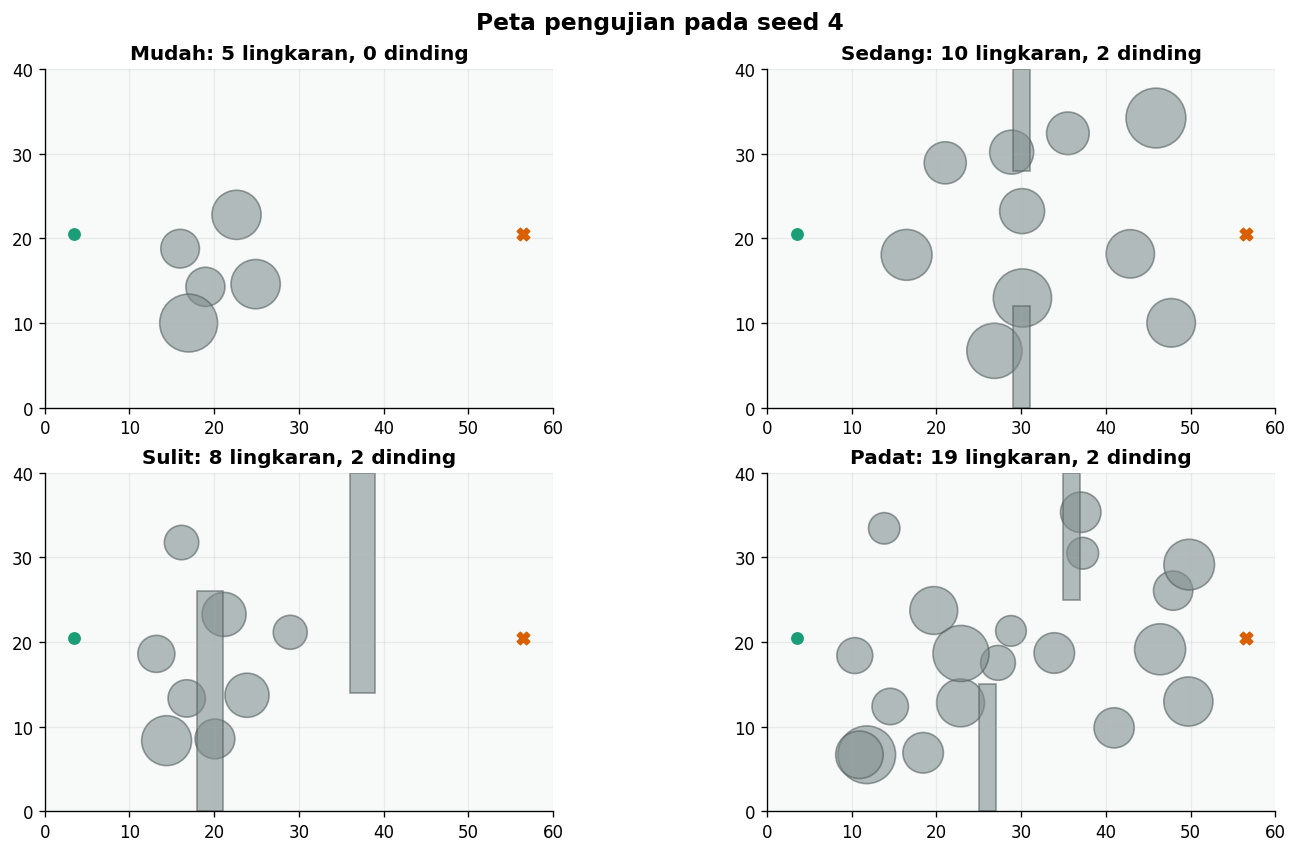

In [3]:
figure, axes = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)
scenario_seed = 4

for axis, kind in zip(axes.flat, SCENARIOS):
    scenario = scenario_from_seed(kind, 1000 * len(kind) + scenario_seed)
    draw_field(
        axis,
        scenario,
        f"{kind}: {len(scenario.circles)} lingkaran, {len(scenario.rects)} dinding",
    )

figure.suptitle("Peta pengujian pada seed 4", fontsize=14, fontweight="bold")
plt.show()

## Satu percobaan lengkap: Sulit, seed 4

Kelima algoritma dijalankan langsung pada peta yang sama. Waktu pada tabel ini
hanya menggambarkan eksekusi kernel saat ini; pembahasan runtime antarskenario
memakai data sepuluh seed.

In [4]:
difficult_map, difficult_results, difficult_table = run_case("Sulit", 4)
display(
    difficult_table.style.format(
        {
            "biaya": "{:.2f}",
            "processed": "{:,.0f}",
            "waktu lokal (ms)": "{:.1f}",
        },
        na_rep="-",
    )
)

assert difficult_table["berhasil"].all()
assert difficult_table["valid"].all()

,berhasil,biaya,processed,titik lintasan,valid,waktu lokal (ms)
algoritma,,,,,,
Brute Force,True,66.13,"12,721",5,True,105.7
UCS,True,64.94,"1,820",56,True,408.8
GBFS,True,71.87,82,65,True,11.0
A*,True,64.94,849,56,True,161.0
RRT*,True,80.24,522,24,True,232.3


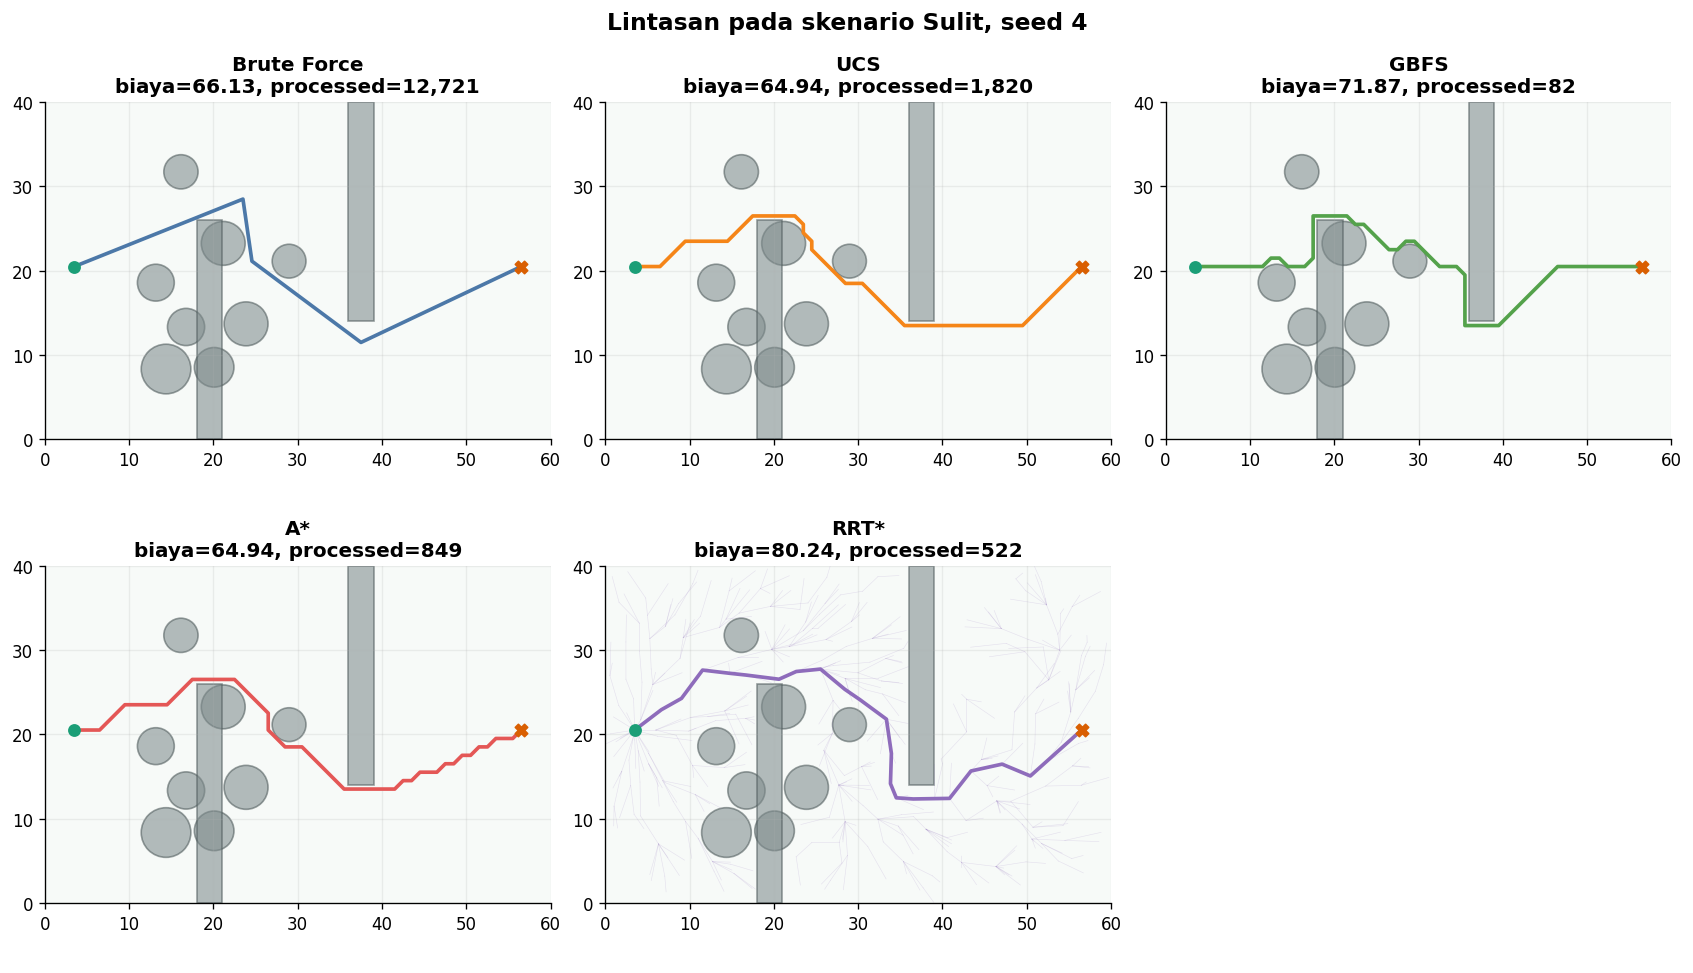

In [5]:
figure, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

for axis, method in zip(axes.flat, ALGORITHM_ORDER):
    result = difficult_results[method]
    draw_field(axis, difficult_map, method)

    if method == "RRT*" and isinstance(result, RRTStarResult):
        for index, parent_index in enumerate(result.parent):
            if parent_index < 0:
                continue
            a = result.nodes[parent_index]
            b = result.nodes[index]
            axis.plot(
                [a[0], b[0]],
                [a[1], b[1]],
                color=COLORS[method],
                linewidth=0.35,
                alpha=0.18,
            )

    if result.success:
        xs, ys = path_xy(method, result.path)
        axis.plot(xs, ys, color=COLORS[method], linewidth=2.2)
        axis.set_title(
            f"{method}\nbiaya={result.cost:.2f}, processed={result.processed:,}"
        )

axes.flat[-1].axis("off")
figure.suptitle("Lintasan pada skenario Sulit, seed 4", fontsize=14, fontweight="bold")
plt.show()

UCS dan A* menghasilkan biaya yang sama karena keduanya mempertahankan biaya
aktual `g(n)`. GBFS memproses simpul jauh lebih sedikit, tetapi jalurnya dapat
lebih panjang. Brute Force dan RRT* menghasilkan segmen kontinu sehingga
biayanya tidak dibandingkan sebagai optimalitas grid.

## Hasil seluruh percobaan

Dataset terdiri dari 4 skenario x 10 seed x 5 algoritma. `cost` hanya terisi ketika
lintasan ditemukan. Ringkasan menggunakan rata-rata cost dari run yang berhasil
dan tetap menampilkan success rate secara terpisah.

In [6]:
detailed = pd.read_csv(DATA_DIR / "hasil_eksperimen.csv")
summary = pd.read_csv(DATA_DIR / "ringkasan_eksperimen.csv")

detailed["scenario"] = pd.Categorical(detailed["scenario"], SCENARIOS, ordered=True)
detailed["algorithm"] = pd.Categorical(
    detailed["algorithm"], ALGORITHM_ORDER, ordered=True
)
summary["scenario"] = pd.Categorical(summary["scenario"], SCENARIOS, ordered=True)
summary["algorithm"] = pd.Categorical(
    summary["algorithm"], ALGORITHM_ORDER, ordered=True
)

detailed = detailed.sort_values(["scenario", "seed", "algorithm"]).reset_index(drop=True)
summary = summary.sort_values(["scenario", "algorithm"]).reset_index(drop=True)

coverage = detailed.groupby(["scenario", "algorithm"], observed=True).size()
print(f"Jumlah run: {len(detailed)}")
print(f"Seed per pasangan skenario-algoritma: {coverage.min()}-{coverage.max()}")
display(detailed.head(10).round(2))

Jumlah run: 200
Seed per pasangan skenario-algoritma: 10-10


,scenario,seed,algorithm,success,cost,time_ms,expanded,detour_ratio,generation_attempt,timing_repeats,time_min_ms,time_max_ms,width,height,obstacle_count
0,Mudah,0,Brute Force,1,53.55,69.50,12721,1.01,0,3,67.09,72.33,60,40,5
1,Mudah,0,UCS,1,55.49,186.92,2059,1.05,0,3,173.38,233.59,60,40,5
2,Mudah,0,GBFS,1,58.56,4.96,56,1.10,0,3,4.35,6.70,60,40,5
3,Mudah,0,A*,1,55.49,27.13,345,1.05,0,3,25.50,31.14,60,40,5
4,Mudah,0,RRT*,1,57.76,151.71,617,1.09,0,3,138.91,171.01,60,40,5
5,Mudah,1,Brute Force,1,53.32,126.24,12721,1.01,0,3,88.75,163.23,60,40,5
6,Mudah,1,UCS,1,55.49,253.02,2069,1.05,0,3,249.07,333.31,60,40,5
7,Mudah,1,GBFS,1,55.49,6.38,55,1.05,0,3,4.64,8.08,60,40,5
8,Mudah,1,A*,1,55.49,91.93,351,1.05,0,3,61.52,99.65,60,40,5
9,Mudah,1,RRT*,1,55.94,315.17,615,1.06,0,3,307.50,362.21,60,40,5


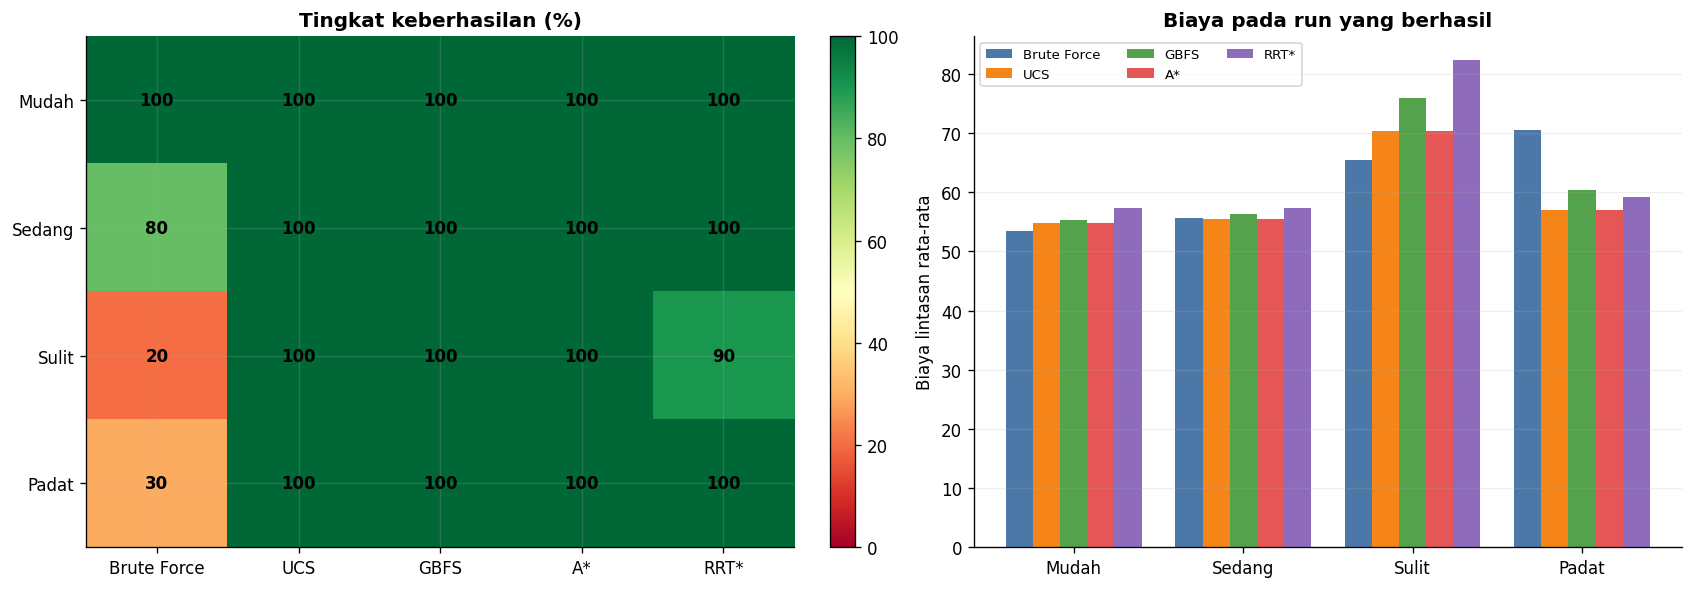

In [7]:
success = (
    summary.pivot(index="scenario", columns="algorithm", values="success_rate")
    .reindex(index=SCENARIOS, columns=ALGORITHM_ORDER)
)
costs = (
    summary.pivot(index="scenario", columns="algorithm", values="avg_cost")
    .reindex(index=SCENARIOS, columns=ALGORITHM_ORDER)
)

figure, (axis_success, axis_cost) = plt.subplots(
    1, 2, figsize=(14, 4.8), constrained_layout=True
)

image = axis_success.imshow(success, cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")
axis_success.set_xticks(range(len(ALGORITHM_ORDER)), ALGORITHM_ORDER)
axis_success.set_yticks(range(len(SCENARIOS)), SCENARIOS)
axis_success.set_title("Tingkat keberhasilan (%)")
for row in range(len(SCENARIOS)):
    for column in range(len(ALGORITHM_ORDER)):
        axis_success.text(
            column,
            row,
            f"{success.iloc[row, column]:.0f}",
            ha="center",
            va="center",
            fontweight="bold",
        )
figure.colorbar(image, ax=axis_success, fraction=0.046)

x = np.arange(len(SCENARIOS))
width = 0.16
for index, method in enumerate(ALGORITHM_ORDER):
    axis_cost.bar(
        x + (index - 2) * width,
        costs[method],
        width,
        color=COLORS[method],
        label=method,
    )
axis_cost.set_xticks(x, SCENARIOS)
axis_cost.set_ylabel("Biaya lintasan rata-rata")
axis_cost.set_title("Biaya pada run yang berhasil")
axis_cost.legend(ncols=3, fontsize=8)
axis_cost.grid(axis="x", visible=False)

plt.show()

Brute Force kehilangan banyak run pada skenario Sulit dan Padat. RRT* juga turun
menjadi 80% pada dua skenario tersebut. UCS, GBFS, dan A* memiliki success rate
yang sama pada setiap peta; perbedaannya muncul pada kualitas rute dan banyaknya
simpul yang dibuka.

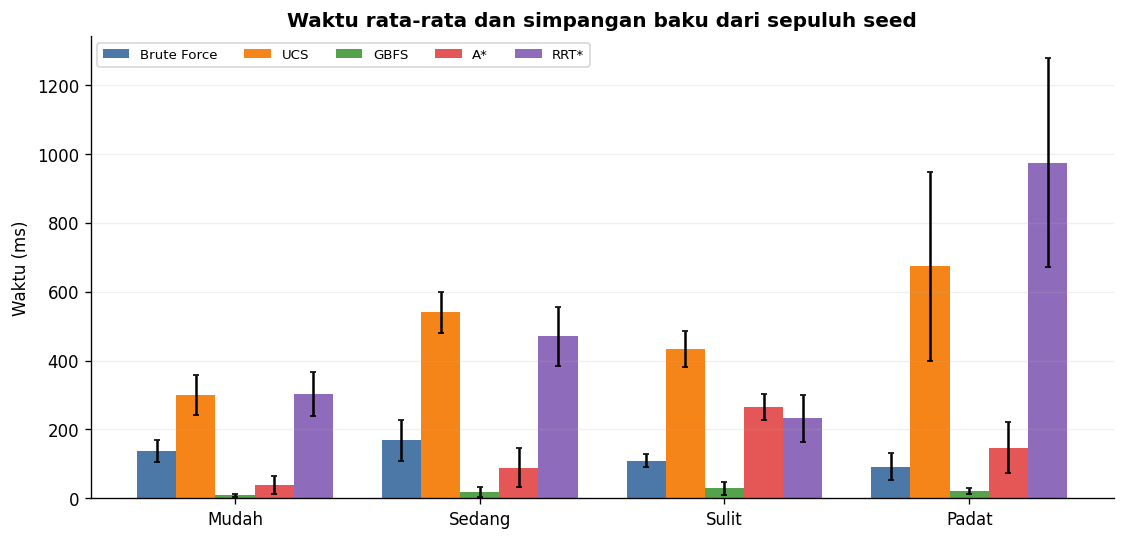

In [8]:
runtime_mean = (
    summary.pivot(index="scenario", columns="algorithm", values="avg_time_ms")
    .reindex(index=SCENARIOS, columns=ALGORITHM_ORDER)
)
runtime_std = (
    summary.pivot(index="scenario", columns="algorithm", values="std_time_ms")
    .reindex(index=SCENARIOS, columns=ALGORITHM_ORDER)
)

figure, axis = plt.subplots(figsize=(11, 5))
x = np.arange(len(SCENARIOS))
width = 0.16

for index, method in enumerate(ALGORITHM_ORDER):
    axis.bar(
        x + (index - 2) * width,
        runtime_mean[method],
        width,
        yerr=runtime_std[method],
        capsize=2,
        color=COLORS[method],
        label=method,
    )

axis.set_xticks(x, SCENARIOS)
axis.set_ylabel("Waktu (ms)")
axis.set_title("Waktu rata-rata dan simpangan baku dari sepuluh seed")
axis.legend(ncols=5, fontsize=8)
axis.grid(axis="x", visible=False)
axis.set_ylim(bottom=0)
plt.show()

GBFS menjadi pencarian grid tercepat, sedangkan UCS membayar eksplorasi yang lebih
luas. Error bar pada skenario Padat cukup besar, sehingga selisih runtime kecil
tidak layak dibaca sebagai peringkat yang stabil tanpa menambah jumlah seed.

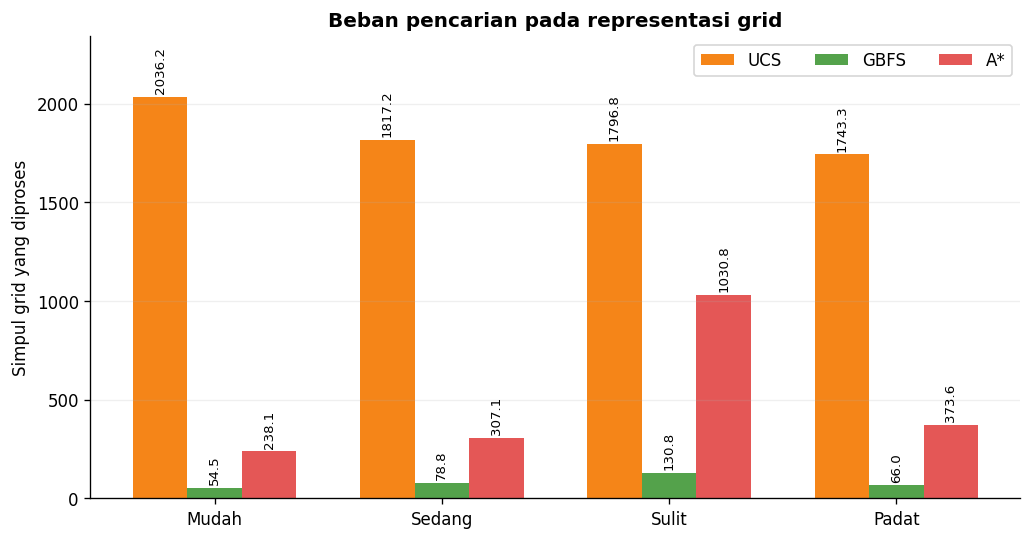

In [9]:
grid_methods = ["UCS", "GBFS", "A*"]
processed = (
    summary[summary["algorithm"].isin(grid_methods)]
    .pivot(index="scenario", columns="algorithm", values="avg_expanded")
    .reindex(index=SCENARIOS, columns=grid_methods)
)

figure, axis = plt.subplots(figsize=(10, 5))
x = np.arange(len(SCENARIOS))
width = 0.24

for index, method in enumerate(grid_methods):
    bars = axis.bar(
        x + (index - 1) * width,
        processed[method],
        width,
        color=COLORS[method],
        label=method,
    )
    axis.bar_label(bars, fmt="%.1f", padding=2, fontsize=8, rotation=90)

axis.set_xticks(x, SCENARIOS)
axis.set_ylabel("Simpul grid yang diproses")
axis.set_title("Beban pencarian pada representasi grid")
axis.legend(ncols=3)
axis.grid(axis="x", visible=False)
axis.set_ylim(0, processed.to_numpy().max() * 1.15)
plt.show()

## Mengapa processed A* meningkat pada skenario Sulit?

Pada Mudah dan Sedang, A* hanya memproses sekitar 12% dari simpul UCS. Pada Sulit,
porsinya naik menjadi 57,4%. Pola ini dapat dibaca bersama kebutuhan detour:
biaya jalur optimal Sulit jauh lebih besar daripada jarak lurus start-goal.

,biaya optimal grid,faktor detour,UCS processed,A* processed,A* / UCS processed (%)
scenario,,,,,
Mudah,54.74,1.03x,"2,036.2",238.1,11.7%
Sedang,55.40,1.05x,"1,817.2",307.1,16.9%
Sulit,70.35,1.33x,"1,796.8","1,030.8",57.4%
Padat,57.06,1.08x,"1,743.3",373.6,21.4%


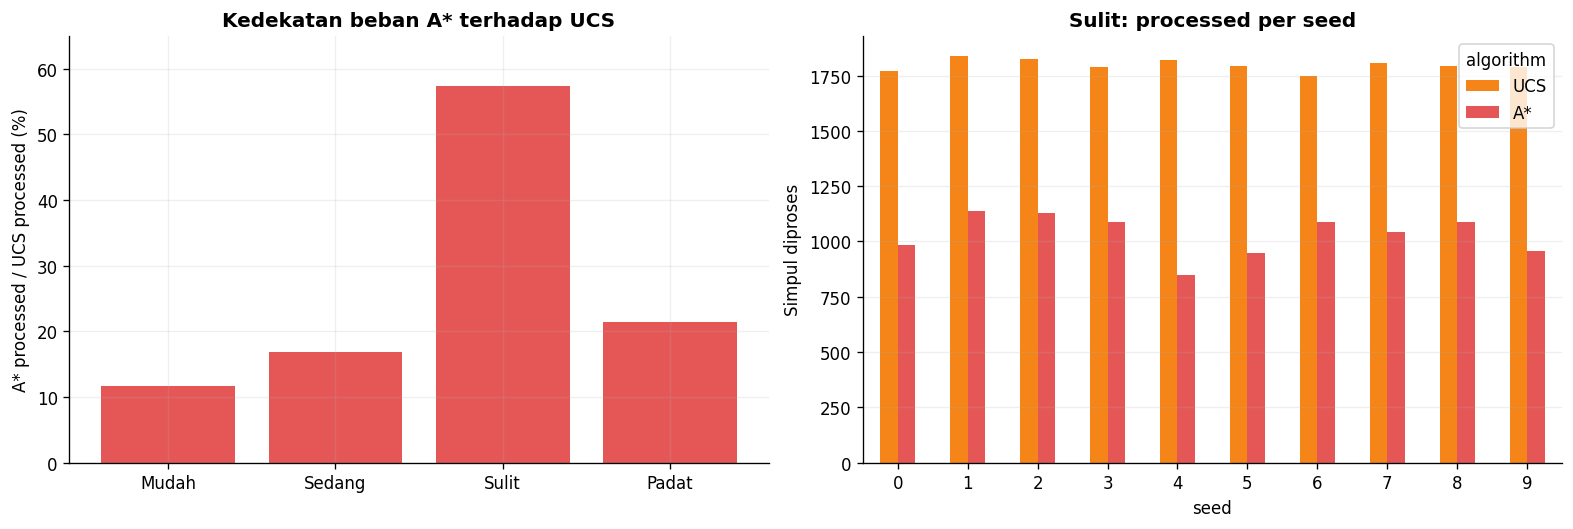

In [10]:
straight_line = math.dist(START, GOAL)
ucs = summary[summary["algorithm"] == "UCS"].set_index("scenario")
astar = summary[summary["algorithm"] == "A*"].set_index("scenario")

diagnostics = pd.DataFrame(
    {
        "biaya optimal grid": astar["avg_cost"],
        "faktor detour": astar["avg_cost"] / straight_line,
        "UCS processed": ucs["avg_expanded"],
        "A* processed": astar["avg_expanded"],
        "A* / UCS processed (%)": (
            astar["avg_expanded"] / ucs["avg_expanded"] * 100
        ),
    }
).reindex(SCENARIOS)

display(
    diagnostics.style.format(
        {
            "biaya optimal grid": "{:.2f}",
            "faktor detour": "{:.2f}x",
            "UCS processed": "{:,.1f}",
            "A* processed": "{:,.1f}",
            "A* / UCS processed (%)": "{:.1f}%",
        }
    )
)

difficult_seeds = (
    detailed[
        (detailed["scenario"] == "Sulit")
        & detailed["algorithm"].isin(["UCS", "A*"])
    ]
    .pivot(index="seed", columns="algorithm", values="expanded")
    .reindex(columns=["UCS", "A*"])
)

figure, (axis_ratio, axis_seed) = plt.subplots(
    1, 2, figsize=(13, 4.3), constrained_layout=True
)
shares = diagnostics["A* / UCS processed (%)"]
axis_ratio.bar(SCENARIOS, shares, color=COLORS["A*"])
axis_ratio.set_ylabel("A* processed / UCS processed (%)")
axis_ratio.set_title("Kedekatan beban A* terhadap UCS")
axis_ratio.set_ylim(0, 65)

difficult_seeds.plot(
    kind="bar",
    ax=axis_seed,
    color=[COLORS["UCS"], COLORS["A*"]],
    rot=0,
)
axis_seed.set_ylabel("Simpul diproses")
axis_seed.set_title("Sulit: processed per seed")
axis_seed.grid(axis="x", visible=False)
plt.show()

Dua dinding pada skenario Sulit memaksa jalur menjauh dari arah langsung menuju
goal. Dalam kondisi ini, jarak Euclidean tetap admissible tetapi kurang tajam:
banyak simpul mempunyai estimasi `h(n)` yang terlihat baik meskipun jalur bebas
hambatan menuju goal masih memerlukan putaran. A* karena itu membuka lebih banyak
simpul sebelum memastikan jalur berbiaya minimum.

Hubungan tersebut konsisten pada sepuluh seed, tetapi tetap merupakan interpretasi
terhadap pola eksperimen. Analisis frontier per langkah diperlukan untuk
mengukur langsung seberapa besar informasi heuristik berkurang.

## Variasi metode sampling

RRT* membangun pohon berbeda untuk setiap seed. Jumlah node, keberhasilan, dan
biaya tidak bergerak seragam karena sampel yang berguna bergantung pada bentuk
ruang bebas.

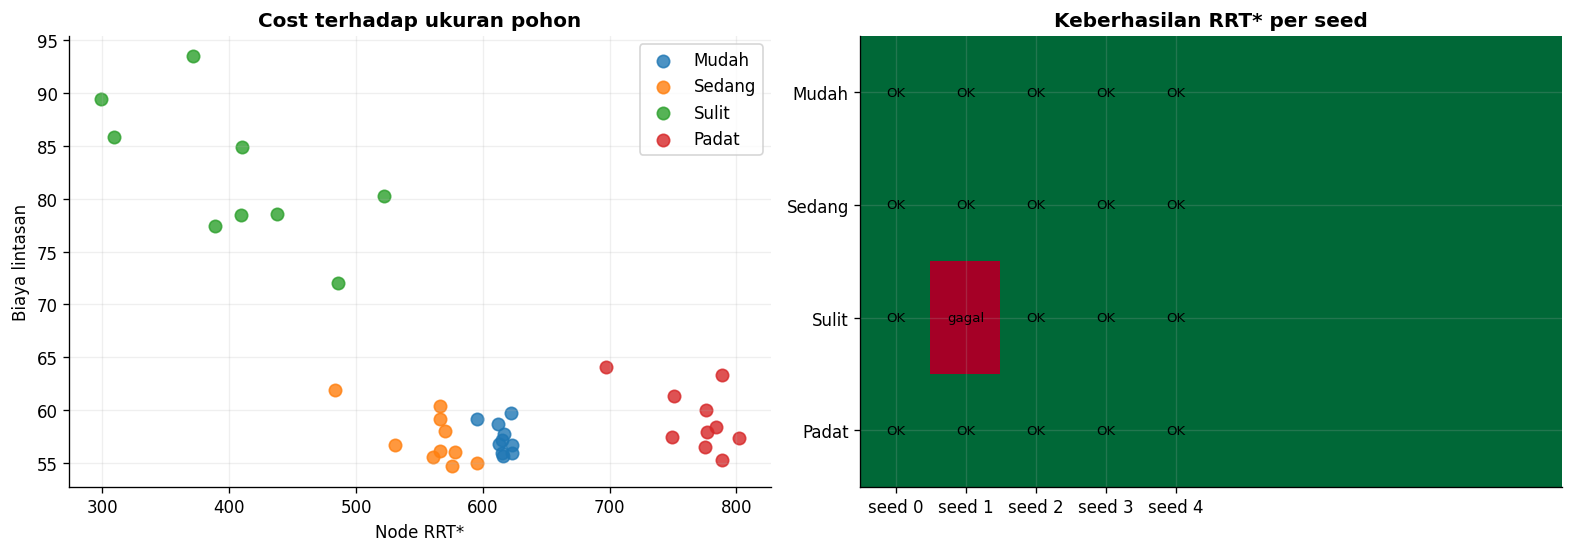

In [11]:
rrt = detailed[detailed["algorithm"] == "RRT*"].copy()

figure, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
for kind in SCENARIOS:
    subset = rrt[(rrt["scenario"] == kind) & (rrt["success"] == 1)]
    axes[0].scatter(
        subset["expanded"],
        subset["cost"],
        s=55,
        label=kind,
        alpha=0.8,
    )
axes[0].set_xlabel("Node RRT*")
axes[0].set_ylabel("Biaya lintasan")
axes[0].set_title("Cost terhadap ukuran pohon")
axes[0].legend()

success_by_seed = (
    rrt.pivot(index="seed", columns="scenario", values="success")
    .reindex(columns=SCENARIOS)
)
axes[1].imshow(success_by_seed.T, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
axes[1].set_xticks(range(5), [f"seed {seed}" for seed in range(5)])
axes[1].set_yticks(range(len(SCENARIOS)), SCENARIOS)
axes[1].set_title("Keberhasilan RRT* per seed")
for row in range(len(SCENARIOS)):
    for column in range(5):
        label = "OK" if success_by_seed.iloc[column, row] else "gagal"
        axes[1].text(column, row, label, ha="center", va="center", fontsize=8)

plt.show()

## Pemeriksaan konsistensi

Pemeriksaan berikut memastikan dataset lengkap dan klaim utama A* terhadap UCS
berasal dari data yang sama dengan tabel dan gambar.

In [12]:
assert len(detailed) == len(SCENARIOS) * 10 * len(ALGORITHM_ORDER)
assert set(detailed["algorithm"].astype(str)) == set(ALGORITHM_ORDER)
assert coverage.eq(10).all()

ucs_runs = (
    detailed[detailed["algorithm"] == "UCS"]
    .set_index(["scenario", "seed"])
    .sort_index()
)
astar_runs = (
    detailed[detailed["algorithm"] == "A*"]
    .set_index(["scenario", "seed"])
    .sort_index()
)

assert ucs_runs["success"].equals(astar_runs["success"])
assert np.allclose(
    ucs_runs["cost"].fillna(-1),
    astar_runs["cost"].fillna(-1),
)

reduction = (1 - astar["avg_expanded"] / ucs["avg_expanded"]) * 100
checks = pd.Series(
    {
        "200 run tersedia": len(detailed) == 200,
        "setiap kombinasi memiliki 10 seed": coverage.eq(10).all(),
        "success UCS dan A* identik": ucs_runs["success"].equals(astar_runs["success"]),
        "cost UCS dan A* identik": np.allclose(
            ucs_runs["cost"].fillna(-1),
            astar_runs["cost"].fillna(-1),
        ),
        "rentang reduksi processed A* benar": (
            reduction.min() > 0
            and reduction.max() < 100
        ),
    },
    name="lolos",
)
display(checks.to_frame())

,lolos
200 run tersedia,True
setiap kombinasi memiliki 10 seed,True
success UCS dan A* identik,True
cost UCS dan A* identik,True
rentang reduksi processed A* benar,True


## Kesimpulan

A* memberikan kompromi paling kuat pada representasi grid: cost dan success rate
sama dengan UCS, tetapi jumlah simpul yang diproses lebih rendah. Keunggulan itu
mengecil pada skenario Sulit karena hambatan memaksa detour dan mengurangi daya
arah heuristik Euclidean. GBFS tetap paling hemat ekspansi, dengan konsekuensi
jalur tidak selalu minimum. Brute Force berguna sebagai baseline enumeratif,
sedangkan RRT* lebih sesuai untuk pengembangan ruang kontinu tetapi memerlukan
lebih banyak seed dan tuning agar kestabilannya dapat dinilai dengan baik.

## Audit validitas dan eksperimen tambahan

Peta utama diterima hanya jika A* menemukan koneksi start-goal. Pemeriksaan
ini memisahkan kegagalan algoritma dari peta yang memang tidak memiliki
lintasan. Kolom `generation_attempt` mencatat berapa kali generator harus
melakukan resampling deterministik.

In [13]:
generation_audit = (
    detailed.groupby(["scenario", "seed"], observed=True)["generation_attempt"]
    .first()
    .unstack(0)
)
grid_success = detailed[detailed["algorithm"].isin(["UCS", "GBFS", "A*"])]["success"]

display(generation_audit)
assert grid_success.eq(1).all()
assert detailed.groupby(["scenario", "algorithm"], observed=True).size().eq(10).all()
print("Semua peta utama feasible; resampling maksimum:", int(generation_audit.max().max()))

scenario,Mudah,Sedang,Sulit,Padat
seed,,,,
0,0,0,0,0
1,0,0,0,1
2,0,0,0,0
3,0,0,0,0
4,0,0,0,0
5,0,0,0,0
6,0,0,0,0
7,0,0,0,0
8,0,0,0,0


Semua peta utama feasible; resampling maksimum: 1


## Skalabilitas resolusi grid

Geometri ternormalisasi yang sama diuji pada enam resolusi. Regresi log-log
digunakan sebagai deskripsi empiris pada rentang ini, bukan sebagai bukti
kompleksitas asimtotik umum.

,algorithm,runtime_exponent,runtime_r2,processed_exponent,processed_r2
0,A*,0.989,0.999,0.960,1.000
1,GBFS,0.683,0.996,0.658,0.991
2,UCS,1.005,1.000,0.997,1.000


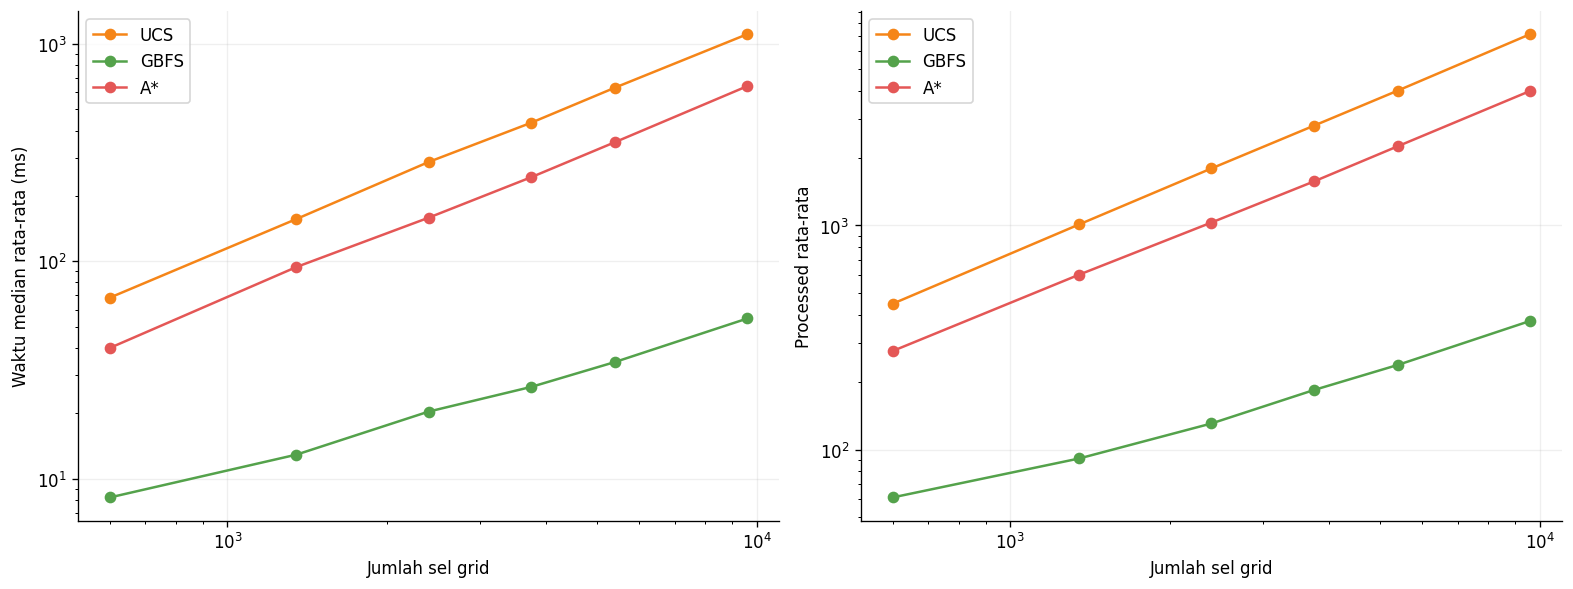

In [14]:
scaling = pd.read_csv(DATA_DIR / "ringkasan_grid_scaling.csv")
scaling_fits = (
    scaling.groupby("algorithm", as_index=False)
    .first()[
        [
            "algorithm",
            "runtime_exponent",
            "runtime_r2",
            "processed_exponent",
            "processed_r2",
        ]
    ]
)
display(scaling_fits.round(3))

figure, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
for method in ["UCS", "GBFS", "A*"]:
    group = scaling[scaling["algorithm"] == method].sort_values("cell_count")
    axes[0].plot(group["cell_count"], group["avg_time_ms"], "o-", color=COLORS[method], label=method)
    axes[1].plot(group["cell_count"], group["avg_expanded"], "o-", color=COLORS[method], label=method)
for axis, ylabel in zip(axes, ["Waktu median rata-rata (ms)", "Processed rata-rata"]):
    axis.set_xscale("log")
    axis.set_yscale("log")
    axis.set_xlabel("Jumlah sel grid")
    axis.set_ylabel(ylabel)
    axis.legend()
plt.show()

## Robustness terhadap kepadatan hambatan

Setiap seed menggunakan daftar hambatan yang nested: peta 8 hambatan
mempertahankan empat hambatan pertama dari peta 4, dan seterusnya. Semua
peta dipastikan mempunyai lintasan, sehingga penurunan success rate berasal
dari keterbatasan metode.

,algorithm,success_rate,avg_detour_ratio,avg_time_ms
25,Brute Force,50.0,1.008,114.242
26,UCS,100.0,1.069,701.878
27,GBFS,100.0,1.108,23.878
28,A*,100.0,1.069,154.624
29,RRT*,100.0,1.134,496.181


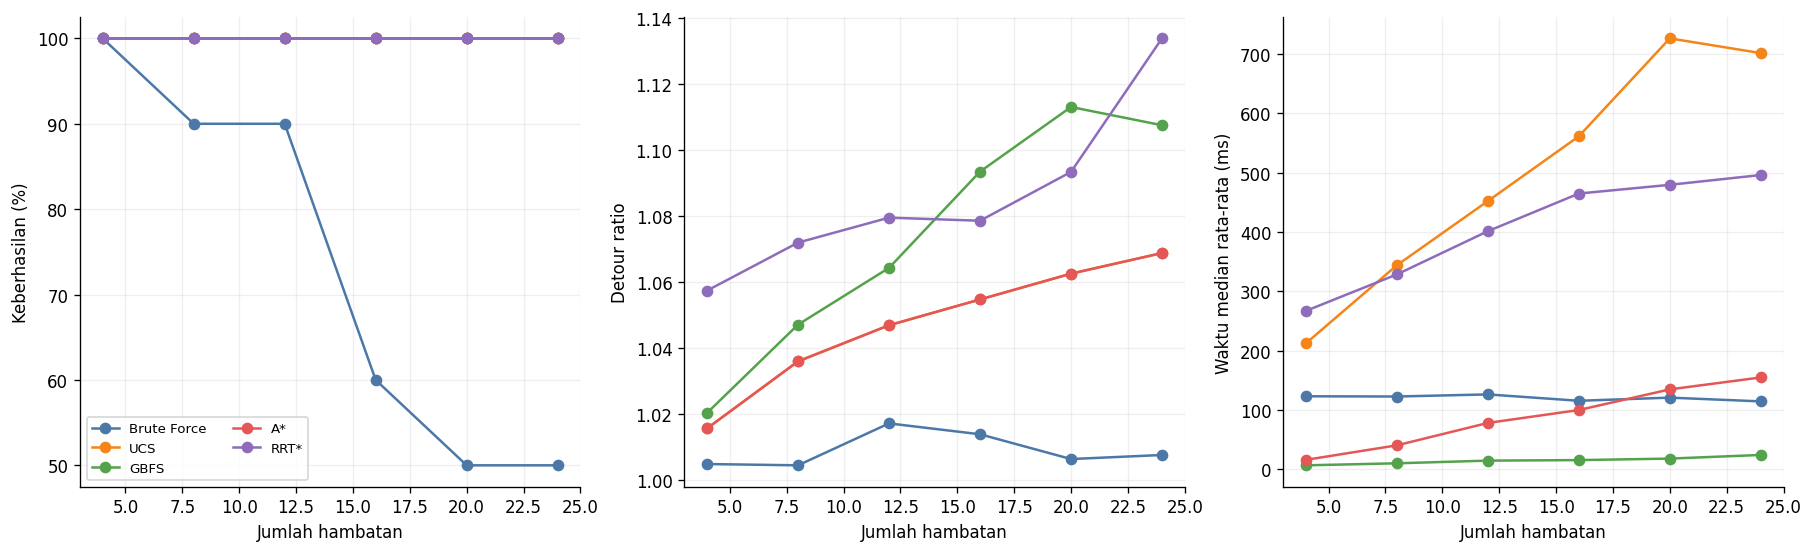

In [15]:
density = pd.read_csv(DATA_DIR / "ringkasan_density_sweep.csv")
density_24 = density[density["density"] == 24][
    ["algorithm", "success_rate", "avg_detour_ratio", "avg_time_ms"]
]
display(density_24.round(3))

figure, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
for method in ALGORITHM_ORDER:
    group = density[density["algorithm"] == method].sort_values("density")
    axes[0].plot(group["density"], group["success_rate"], "o-", color=COLORS[method], label=method)
    axes[1].plot(group["density"], group["avg_detour_ratio"], "o-", color=COLORS[method])
    axes[2].plot(group["density"], group["avg_time_ms"], "o-", color=COLORS[method])
axes[0].set_ylabel("Keberhasilan (%)")
axes[1].set_ylabel("Detour ratio")
axes[2].set_ylabel("Waktu median rata-rata (ms)")
for axis in axes:
    axis.set_xlabel("Jumlah hambatan")
    axis.grid(alpha=0.2)
axes[0].legend(ncols=2, fontsize=8)
plt.show()

Detour ratio memungkinkan kualitas lintasan dibandingkan lintas representasi
karena setiap biaya dibagi jarak lurus start-goal. Pada 24 hambatan, UCS dan
A* tetap menghasilkan kualitas grid yang sama, GBFS lebih cepat dengan detour
lebih besar, dan Brute Force kehilangan reliabilitas meskipun peta feasible.